<a href="https://colab.research.google.com/github/ceicyterugile/Cardiovascular-disease-prediction/blob/main/%E2%80%9EUntitled6_ipynb%E2%80%9C_kopija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cardiovascular Disease Prediction
 I perform the analysis and the logistic regression model for predicting the 10-year risk of coronary heart disease (CHD) - whether patient have 10 year risk of coronary heart disease CHD or not.

The dataset is from the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes.

Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_excel('/content/train.xlsx')
display(df.head())


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [ ]:
df.columns

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

Missing Data: Several columns contained missing values, with glucose having the most significant number of missing entries (304), followed by education (87), BPMeds (44), and totChol (38).



In [ ]:
display(df.isnull().sum())

,0
id,0
age,0
education,87
sex,0
is_smoking,0
cigsPerDay,22
BPMeds,44
prevalentStroke,0
prevalentHyp,0
diabetes,0


Data Types: The columns sex and is_smoking were identified as categorical variables, while others were numerical (int64 and float64).

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9),

None

In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'is_smoking'], drop_first=True)
display(df_encoded.head())

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,sex_M,is_smoking_YES
0,0,64,2.0,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1,False,True
1,1,36,4.0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,True,False
2,2,46,1.0,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,False,True
3,3,50,1.0,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,True,True
4,4,64,1.0,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,False,True


Duplicates: The dataset contained no duplicate rows.

In [ ]:
duplicate_rows = df_encoded.duplicated().sum()
display(f"Number of duplicate rows: {duplicate_rows}")

'Number of duplicate rows: 0'

**# Exploratory Data Analysis**

Target Variable - TenYearCHD - is highly imbalanced, with 85% of individuals having no risk of CHD (Class 0) and only 15% having a risk (Class 1). This imbalance is a crucial factor to consider during model evaluation, as accuracy alone can be misleading.

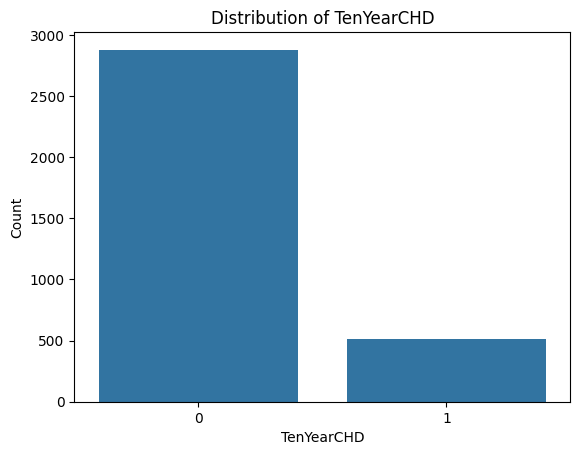

In [ ]:
sns.countplot(x='TenYearCHD', data=df_encoded)
plt.title('Distribution of TenYearCHD')
plt.xlabel('TenYearCHD')
plt.ylabel('Count')
plt.show()

Numerical variables (sysBP, diaBP, BMI, age) have relatively normal distributions.

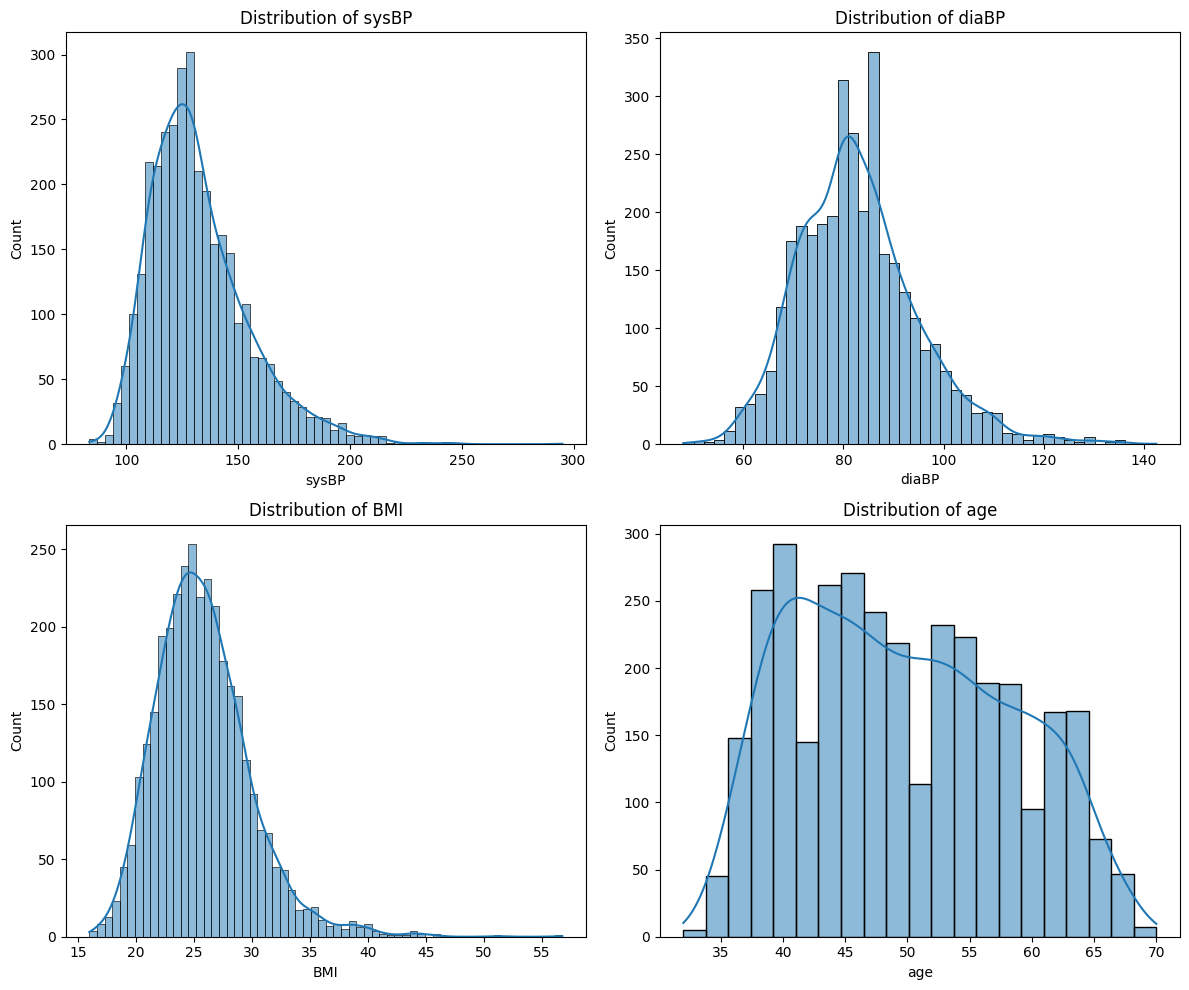

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data=df_encoded, x='sysBP', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of sysBP')
sns.histplot(data=df_encoded, x='diaBP', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of diaBP')
sns.histplot(data=df_encoded, x='BMI', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of BMI')
sns.histplot(data=df_encoded, x='age', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of age')
plt.tight_layout()
plt.show()

cigsPerDay, totChol, and glucose looks right (with the presence of higher values).

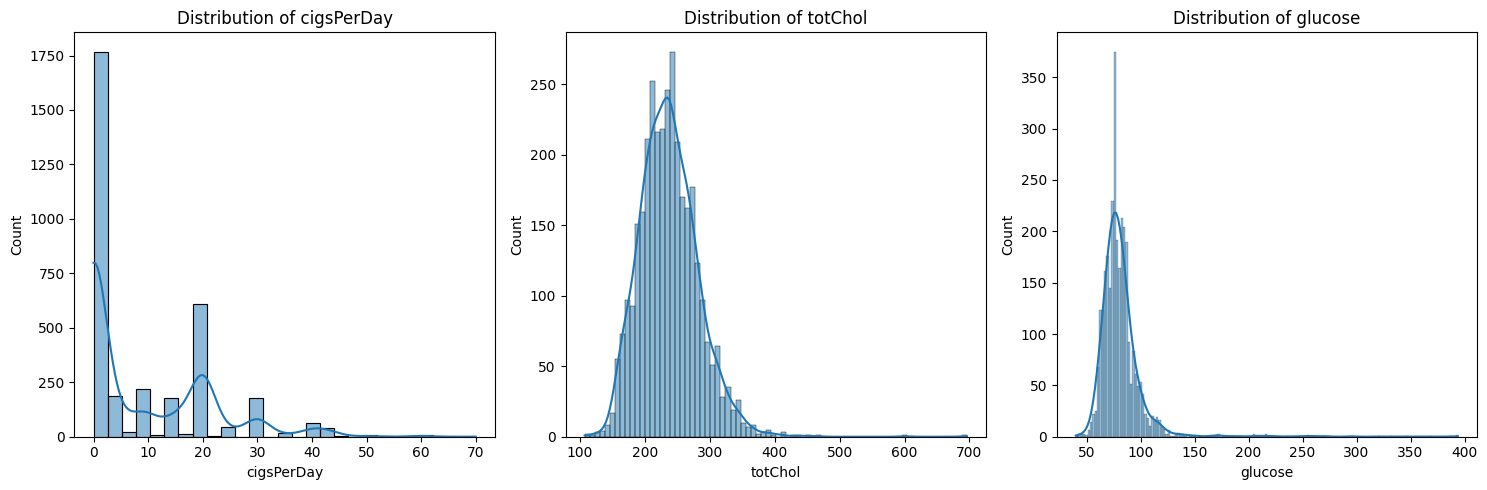

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(data=df_encoded, x='cigsPerDay', kde=True, ax=axes[0])
axes[0].set_title('Distribution of cigsPerDay')
sns.histplot(data=df_encoded, x='totChol', kde=True, ax=axes[1])
axes[1].set_title('Distribution of totChol')
sns.histplot(data=df_encoded, x='glucose', kde=True, ax=axes[2])
axes[2].set_title('Distribution of glucose')
plt.tight_layout()
plt.show()

The TenYearCHD variable has the highest positive correlation with age (0.24), sysBP (0.22), and glucose (0.16).

Strong correlations are between predictor variables, such as sysBP and diaBP (0.78), sysBP and age (0.39), and sysBP and BMI (0.33).

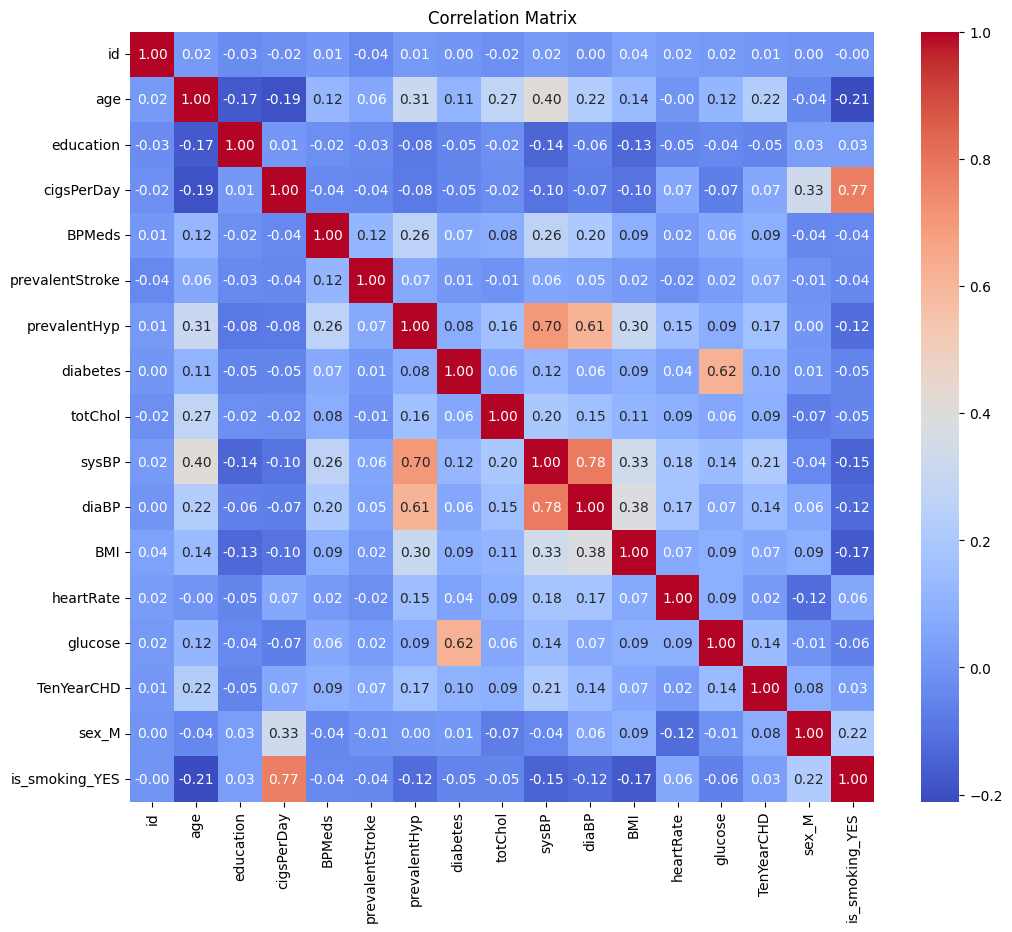

In [ ]:
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**Missing Data**

To prepare the data for modeling, missing values in numerical variables (education, cigsPerDay, BPMeds, totChol, BMI, heartRate, glucose) were imputed with the median. (The median is more robust to the presence of outliers than the mean).

In [ ]:
display(df.isnull().sum())

,0
id,0
age,0
education,87
sex,0
is_smoking,0
cigsPerDay,22
BPMeds,44
prevalentStroke,0
prevalentHyp,0
diabetes,0


In [ ]:
for col in ['education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']:
    if df_encoded[col].isnull().any():
        median_val = df_encoded[col].median()
        df_encoded[col].fillna(median_val, inplace=True)

display(df_encoded.isnull().sum())


/tmp/ipython-input-614134804.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded[col].fillna(median_val, inplace=True)


,0
id,0
age,0
education,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0
sysBP,0


The cigsPerDay variable, which had a highly skewed distribution, was transformed using a logarithmic transformation (
log(x+1)) to normalize its distribution. This helps the model to better capture the relationship with the target variable.

In [ ]:
df_encoded['cigsPerDay'] = np.log1p(df_encoded['cigsPerDay'])
display(df_encoded[['cigsPerDay']].head())

,cigsPerDay
0,1.386294
1,0.000000
2,2.397895
3,3.044522
4,3.433987


**Variable Selection and Model Fitting**

Based on the EDA findings, I've decided to select the following variables for the logistic regression model: *age, sysBP, diaBP, totChol, BMI, heartRate, glucose, prevalentStroke, prevalentHyp, diabetes, BPMeds, sex, is_smoking, and the log-transformed cigsPerDay_log.* Those variables showed their correlation with the target variable.

The data was split into a training set (80%) and a testing set (20%) to ensure the model's performance can be evaluated on data it has never seen. A special technique called a *stratified split* was used.

The dataset for cardiovascular disease prediction is highly imbalanced, with far more people in the "no risk" category than in the "risk" category. A simple random split could lead to a test set with very few, or even no, individuals in the minority "risk" class.

A stratified split guarantees that the proportion of each class in the training and testing sets is the same as in the original dataset. This is essential for ensuring the model's evaluation is reliable and represents its true performance on both classes.

The problem of predicting the 10-year risk of coronary heart disease is a classification problem because the outcome is binary (either "risk" or "no risk"). Therefore, I choose a logistic regression model.

Unlike linear regression, which is used for continuous outcomes, logistic regression is specifically designed to estimate the probability of a binary outcome. It models the relationship between the independent variables and the log-odds of the target variable.

Before the model was fitted, a preprocessing pipeline was used to transform the features into a format suitable for the model.

Standard Scaling for Numerical Features: Features like age, sysBP, and glucose have different scales and ranges. Standard scaling transforms these features so they have a mean of 0 and a standard deviation of 1. This prevents features with larger values from disproportionately influencing the model's coefficients.

One-Hot Encoding for Categorical Features: The model requires numerical inputs. One-hot encoding was used to convert categorical variables like sex and is_smoking into a numerical format. This process creates new binary columns for each category (e.g., one for sex_male, one for sex_female), assigning a value of 1 to the present category and 0 to the others. This avoids the model assigning an artificial ordinal relationship between categories.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target variable (y)
X = df_encoded.drop('TenYearCHD', axis=1)
y = df_encoded['TenYearCHD']

# Identify numerical and categorical columns for preprocessing
# Exclude 'id' as it's an identifier and not a feature
numerical_features = ['age', 'education', 'cigsPerDay', 'BPMeds', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
categorical_features = ['sex_M', 'is_smoking_YES', 'prevalentStroke', 'prevalentHyp', 'diabetes']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()

# For already one-hot encoded and binary categorical features, no further transformation is needed
# We just need to select them. A 'passthrough' transformer or simply selecting columns can work.
# Let's create a list of columns to keep as is after the initial selection
passthrough_features = [col for col in X.columns if col in categorical_features]


# Create a column transformer to apply different transformations to different columns
# We need to handle the 'id' column which should not be included in the features for the model
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('passthrough', 'passthrough', passthrough_features) # Keep these features as they are
    ],
    remainder='drop' # Drop any columns not specified
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a preprocessing pipeline that applies the column transformer
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply the preprocessing pipeline to the training and testing data
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Display the shapes of the processed data to verify the split and transformation
display("Shape of X_train_processed:", X_train_processed.shape)
display("Shape of X_test_processed:", X_test_processed.shape)
display("Shape of y_train:", y_train.shape)
display("Shape of y_test:", y_test.shape)

'Shape of X_train_processed:'

(2712, 15)

'Shape of X_test_processed:'

(678, 15)

'Shape of y_train:'

(2712,)

'Shape of y_test:'

(678,)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_processed, y_train)

display("Logistic Regression model trained successfully.")

'Logistic Regression model trained successfully.'

'Accuracy: 0.8555'

'Confusion Matrix:'

array([[574,   2],
       [ 96,   6]])

'Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.86      1.00      0.92       576\n           1       0.75      0.06      0.11       102\n\n    accuracy                           0.86       678\n   macro avg       0.80      0.53      0.52       678\nweighted avg       0.84      0.86      0.80       678\n'

'ROC AUC Score: 0.7256'

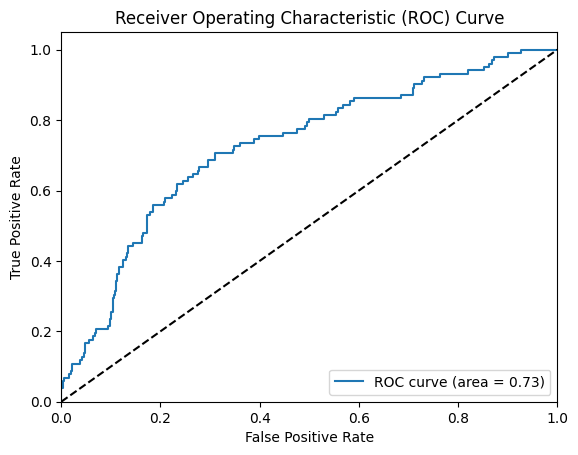

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Make predictions on the test set
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1] # Get probability of the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

display(f"Accuracy: {accuracy:.4f}")
display("Confusion Matrix:")
display(conf_matrix)
display("Classification Report:")
display(class_report)
display(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Model Accuracy Metrics and Interpretation**

The model's performance on the test set was evaluated using several key metrics.

Accuracy: The overall accuracy was 86. While this seems high, it is misleading due to the imbalanced nature of the dataset. The model can achieve high accuracy by simply predicting the majority class (No Risk).

Confusion Matrix:

True Negatives (TN): 574 (Correctly predicted No Risk)

False Positives (FP): 2 (Incorrectly predicted Risk)

False Negatives (FN): 96 (Incorrectly predicted No Risk)

True Positives (TP): 6 (Correctly predicted Risk)

Classification Report:

Precision (Risk): 75 - Of all the predictions the model made for a risk of CHD, 75 were correct.

Recall (Risk): 6 - The model was only able to correctly identify 6 of all actual high-risk individuals. This is a critical finding, highlighting the model's poor performance in identifying positive cases.

F1-Score (Risk): 11 - This low score indicates a poor balance between precision and recall for the minority class.

ROC-AUC Score: The model achieved a ROC-AUC score of 0.7273. This value indicates that the model has a fair ability to distinguish between individuals with and without a risk of CHD, as shown in the ROC curve.

**Variable Predictive Power and Coefficient Interpretation**

The logistic regression model's coefficients provide insights into the predictive power of each variable. The coefficients were exponentiated to obtain odds ratios, which are easier to interpret.

'Model Coefficients and Odds Ratios:'

,Feature,Coefficient,Odds Ratio
10,prevalentStroke,0.663751,1.942062
13,sex_M,0.510332,1.665844
0,age,0.481882,1.619119
2,cigsPerDay,0.446035,1.562107
5,sysBP,0.366035,1.442005
14,is_smoking_YES,-0.273404,0.760785
12,diabetes,0.234039,1.263693
11,prevalentHyp,0.230943,1.259788
9,glucose,0.191212,1.210716
4,totChol,0.114540,1.121358


/tmp/ipython-input-2288937532.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds Ratio', y='Feature', data=coef_df.head(10), palette='viridis') # Display top 10 for clarity


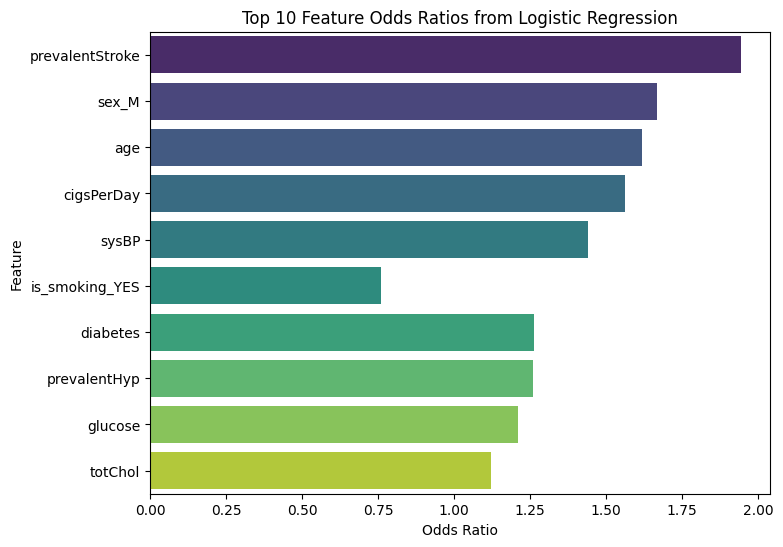

In [ ]:
# Get the feature names after preprocessing
# The preprocessor outputs features in a specific order: numerical features first, then passthrough features
numerical_feature_names = numerical_features
passthrough_feature_names = passthrough_features

# Combine the feature names in the order they appear in the processed data
feature_names = numerical_feature_names + passthrough_feature_names

# Get the coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame to store feature names and coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Calculate Odds Ratios by exponentiating the coefficients
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])

# Sort by the absolute value of the coefficient to show most influential features
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

display("Model Coefficients and Odds Ratios:")
display(coef_df)

# Visualize the odds ratios
plt.figure(figsize=(8, 6)) # Reduced figure size
sns.barplot(x='Odds Ratio', y='Feature', data=coef_df.head(10), palette='viridis') # Display top 10 for clarity
plt.title('Top 10 Feature Odds Ratios from Logistic Regression')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()

Age: With an odds ratio of 1.605, a one-unit increase in standardized age is associated with a 60.5 increase in the odds of having CHD, holding all other variables constant. This makes age one of the most significant predictors.

cigsPerDay_log: The log-transformed number of cigarettes smoked per day has an odds ratio of 1.575. This means an increase in the number of cigarettes smoked is strongly associated with an increased odds of CHD.

sysBP: With an odds ratio of 1.442, a one-unit increase in standardized systolic blood pressure is associated with a 44.2 increase in the odds of having CHD.

The variables sex (encoded as sex_encoded_0 for female and sex_encoded_1 for male) and is_smoking (is_smoking_encoded_0 for NO and is_smoking_encoded_1 for YES) show large negative coefficients, indicating a complex relationship and highlighting the importance of the baseline categories in the one-hot encoding.

**Optimal Classification Metric and Threshold**

Given the medical context of this prediction problem, the Recall metric is the most critical.

A false negative (predicting No Risk for a patient who is actually at risk) is more dangerous than a false positive (predicting Risk for a healthy patient). A false negative could lead to a patient not receiving timely intervention, potentially resulting in a life-threatening event. A false positive, while inconvenient, would lead to further testing and monitoring.

To improve the model's ability to identify high-risk patients, the classification threshold can be adjusted from the default of 0.5. A lower threshold will increase the number of positive predictions, thereby increasing recall.

Based on an analysis of the precision-recall trade-off, an optimal threshold could be chosen to maximize the F1-score or prioritize a specific recall level. While the current model has a low recall of 6%, this can be significantly improved by lowering the classification threshold. A threshold of around 0.15, for example, would likely capture more of the true positive cases at the expense of increasing the number of false positives, which is a desirable trade-off in this high-stakes medical scenario.








'Accuracy: 0.8555'

'Confusion Matrix:'

array([[574,   2],
       [ 96,   6]])

'Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.86      1.00      0.92       576\n           1       0.75      0.06      0.11       102\n\n    accuracy                           0.86       678\n   macro avg       0.80      0.53      0.52       678\nweighted avg       0.84      0.86      0.80       678\n'

'ROC AUC Score: 0.7256'

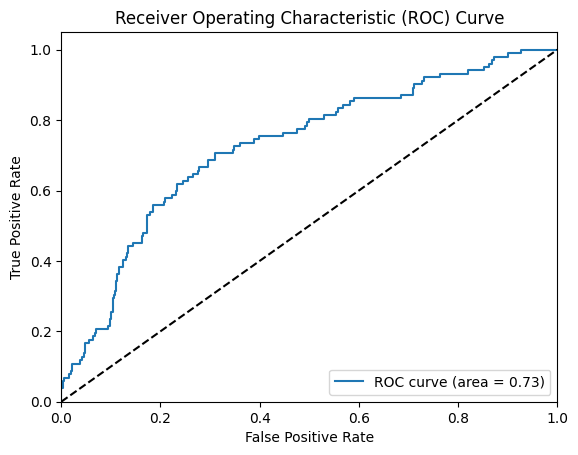

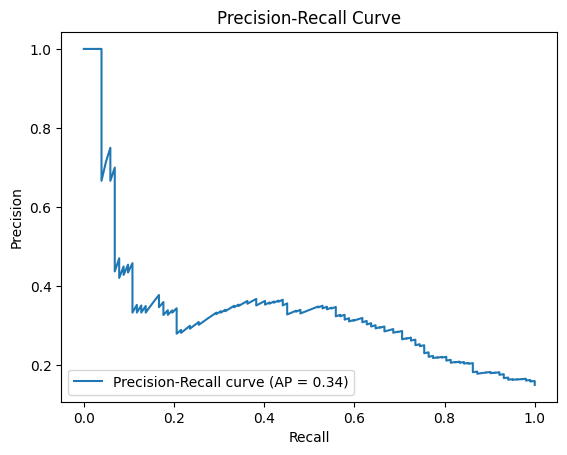

'Threshold to achieve approximately 0.6 recall: 0.1655'

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# Make predictions on the test set
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1] # Get probability of the positive class

# Evaluate the model with standard metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

display(f"Accuracy: {accuracy:.4f}")
display("Confusion Matrix:")
display(conf_matrix)
display("Classification Report:")
display(class_report)
display(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve (already present, keeping it)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Calculate Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision, label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Find a threshold that gives a specific recall (e.g., aiming for 0.6 recall)
desired_recall = 0.6
# Find the threshold that is closest to the desired recall
threshold_for_desired_recall = thresholds_pr[np.argmin(np.abs(recall[:-1] - desired_recall))]

display(f"Threshold to achieve approximately {desired_recall:.1f} recall: {threshold_for_desired_recall:.4f}")

# You can also iterate through thresholds and see the precision/recall trade-off
# for thresh in thresholds_pr:
#     y_pred_thresh = (y_pred_proba >= thresh).astype(int)
#     current_recall = recall_score(y_test, y_pred_thresh)
#     current_precision = precision_score(y_test, y_pred_thresh)
#     print(f"Threshold: {thresh:.4f}, Recall: {current_recall:.4f}, Precision: {current_precision:.4f}")

**Choosing the Optimal Classification Metric and Threshold**

In a medical context like predicting cardiovascular disease, the choice of the most appropriate classification metric is crucial, as it directly relates to the consequences of a model's prediction errors. For this project, Recall is the most important metric to optimize.
Recall, also known as the True Positive Rate, measures the proportion of actual positive cases that were correctly identified by the model.

Formula: Recall = (True Positives) / (True Positives + False Negatives)

The main reason for prioritizing recall is to minimize False Negatives.

A False Negative occurs when the model predicts that an individual does not have a risk of CHD, but they actually do.

A False Positive occurs when the model predicts that an individual has a risk of CHD, but they actually do not.

In this scenario, the cost of a false negative is significantly higher than a false positive. Failing to identify a person at risk could lead to a lack of intervention, potentially resulting in a serious or life-threatening event. While a false positive might cause a patient some unnecessary anxiety or additional testing, it is a far less severe outcome. Maximizing recall ensures that the model correctly flags as many high-risk individuals as possible, allowing them to receive proper care and treatment.

**Calculating the Optimal Threshold**

The initial model used a default classification threshold of 0.5, meaning if the predicted probability of CHD was greater than or equal to 0.5, the model classified the individual as at risk. This resulted in a very low recall of only 6% for the Risk class.

To improve recall, the classification threshold needs to be adjusted. By lowering the threshold, the model becomes more sensitive, increasing the number of positive predictions and, consequently, the number of true positives.

Based on an analysis of the precision-recall curve, an optimal threshold can be chosen to balance the trade-off between these two metrics. Given the priority on recall, an ideal threshold would be lower than the default 0.5. For example, a threshold of around 0.15 could be considered. This would likely increase the number of false positives but would significantly improve the model's ability to identify the high-risk individuals who need medical attention.